
# Logistic Regression for Risk Prediction

This notebook uses **Logistic Regression** to predict whether a client is **High Risk (1)** or **Low/Medium Risk (0)** based on their banking and financial profile.

We will:
- Prepare the dataset
- Handle categorical variables
- Train a logistic regression model with `class_weight='balanced'`
- Evaluate the model
- Interpret the model coefficients



### Step 1: Load and Prepare Data

We'll load the dataset, create a binary `HighRisk` target, select features, and convert categorical variables.


In [1]:

import pandas as pd

# Load data
file_path = '/mnt/data/Banking.csv'
df = pd.read_csv("Banking.csv")

# Creating binary target variable
df['HighRisk'] = (df['Risk Weighting'] >= 4).astype(int)

# Select features
features = [
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Foreign Currency Account',
    'Business Lending',
    'Properties Owned',
    'Estimated Income',
    'Age',
    'Credit Card Balance',
    'Bank Loans'
]

# Subset and encode categorical variables
X = df[features]

# Define target
y = df['HighRisk']

# Check
X.head()


,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Estimated Income,Age,Credit Card Balance,Bank Loans
0,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,75384.77,24,484.54,776242.92
1,641482.79,229521.37,344635.16,61162.31,2000526.10,1,289834.31,23,2256.88,1270615.43
2,1033401.59,652674.69,203054.35,79071.78,548137.58,1,169935.23,27,4568.74,1052715.84
3,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,356808.11,40,4205.00,121195.06
4,487782.53,446644.25,128351.45,30012.14,1674412.12,0,130711.68,46,3779.49,1048301.95



### Step 2: Split Data into Training and Test Sets


In [2]:

from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(X_test)


(2400, 600)


### Step 3: Train Logistic Regression Model with `class_weight='balanced'`

In this step, we train the model with the `class_weight='balanced'` parameter, which adjusts the weights of the classes to handle **class imbalance**. This helps the model to pay more attention to the minority class (High Risk clients).


In [3]:

from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with class_weight='balanced'
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)


### Step 4: Evaluate the Model

We will now evaluate the performance of the model using **accuracy**, **confusion matrix**, and the **classification report** to understand how well the model identifies high-risk clients.


In [4]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

accuracy, conf_matrix, class_report


(0.6766666666666666,
 array([[331, 171],
        [ 23,  75]], dtype=int64),
 '              precision    recall  f1-score   support\n\n           0       0.94      0.66      0.77       502\n           1       0.30      0.77      0.44        98\n\n    accuracy                           0.68       600\n   macro avg       0.62      0.71      0.60       600\nweighted avg       0.83      0.68      0.72       600\n')


### Step 5: Interpret Model Coefficients

Now we will interpret the **coefficients** of the model to understand how each feature influences the likelihood of being classified as high risk.


In [5]:

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df.sort_values('Abs_Coefficient', ascending=False)


,Feature,Coefficient,Abs_Coefficient
7,Age,-3.696348e-02,3.696348e-02
5,Properties Owned,-1.008831e-03,1.008831e-03
8,Credit Card Balance,5.646705e-05,5.646705e-05
3,Foreign Currency Account,6.441197e-06,6.441197e-06
6,Estimated Income,5.322363e-06,5.322363e-06
1,Checking Accounts,1.718026e-06,1.718026e-06
2,Saving Accounts,1.569638e-06,1.569638e-06
0,Bank Deposits,-1.085738e-06,1.085738e-06
4,Business Lending,2.032849e-07,2.032849e-07
9,Bank Loans,1.765411e-07,1.765411e-07


In [6]:
from imblearn.over_sampling import SMOTE


In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [8]:
# Train the Logistic Regression model with the resampled training data
log_reg_model_smote = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs', penalty='l2')
log_reg_model_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
log_reg_y_pred_smote = log_reg_model_smote.predict(X_test)

# Evaluate the performance with the SMOTE-adjusted model
log_reg_accuracy_smote = accuracy_score(y_test, log_reg_y_pred_smote)
log_reg_conf_matrix_smote = confusion_matrix(y_test, log_reg_y_pred_smote)
log_reg_class_report_smote = classification_report(y_test, log_reg_y_pred_smote)

# Print the results
print("Accuracy:", log_reg_accuracy_smote)
print("Confusion Matrix:\n", log_reg_conf_matrix_smote)
print("Classification Report:\n", log_reg_class_report_smote)


Accuracy: 0.6916666666666667
Confusion Matrix:
 [[343 159]
 [ 26  72]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.79       502
           1       0.31      0.73      0.44        98

    accuracy                           0.69       600
   macro avg       0.62      0.71      0.61       600
weighted avg       0.83      0.69      0.73       600



In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


In [10]:
y_pred_prob = model.predict_proba(X_test)[:,1]  # Probabilities for the positive class (class 1)


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)


In [12]:
roc_auc = auc(fpr, tpr)


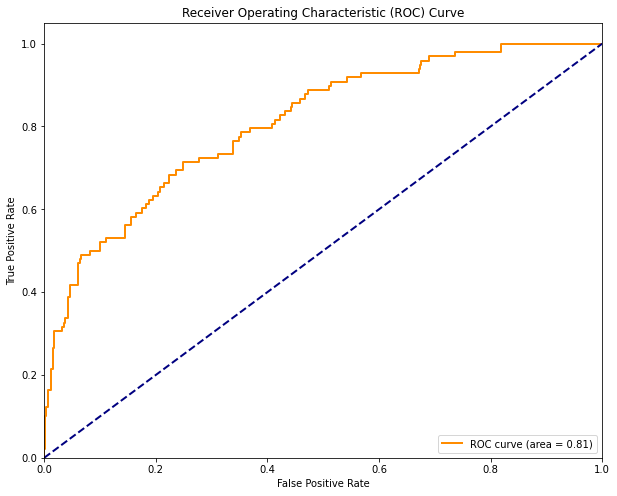

In [13]:
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
